# Notebook 8 — Predicting the Decade from Lyrics

If our previous findings are real — that pop music has distinct eras with different vocabularies, topics, and emotional registers — then a classifier should be able to identify a song's decade from its lyrics alone.

**Tasks:**
1. **Decade classification** (9 classes, baseline = 11%). What accuracy can we reach?
2. **Year regression**: predict the actual year. What's the mean absolute error?
3. **Feature importance**: which words/features most strongly indicate each decade?
4. **Confusion analysis**: which decades are systematically confused?

**Methods compared:**
- TF-IDF + Logistic Regression (interpretable baseline)
- TF-IDF + Linear SVM (often the best classical model for text)
- Sentence embeddings + Gradient Boosting (semantic features)
- Stacked: combine the above

We use **stratified by decade**, with a held-out test set for honest evaluation.

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (13, 5)

PROCESSED_DIR = Path.cwd().parent / "data" / "processed"
df = pd.read_parquet(PROCESSED_DIR / "songs_with_topics.parquet")
print(f"Total songs: {len(df):,}")
print(f"By decade:\n{df['decade'].value_counts().sort_index()}")

Total songs: 6,538
By decade:
decade
1940     82
1950    315
1960    911
1970    946
1980    978
1990    963
2000    967
2010    934
2020    442
Name: count, dtype: int64


## Filter & split

The 1940s have only ~80 songs — far too few for reliable classification. We'll drop them and predict 1950s-2020s (8 classes).

We do a stratified 80/20 train/test split. **Important:** we stratify by decade, not year, so each decade is fairly represented in both sets. The test set will never be touched until final evaluation.

In [2]:
from sklearn.model_selection import train_test_split

# Drop 1940s — too few songs (~80) for reliable classification
df_clf = df[df["decade"] >= 1950].copy().reset_index(drop=True)
print(f"After dropping 1940s: {len(df_clf):,} songs across {df_clf['decade'].nunique()} decades")

# Baseline accuracy = most common class proportion
baseline = df_clf["decade"].value_counts(normalize=True).max()
print(f"Most-common-class baseline accuracy: {baseline*100:.1f}%")
print(f"Random-guess baseline: {100/df_clf['decade'].nunique():.1f}%")

X_train_df, X_test_df = train_test_split(
    df_clf,
    test_size=0.2,
    stratify=df_clf["decade"],
    random_state=42,
)
print(f"\nTrain: {len(X_train_df):,}")
print(f"Test:  {len(X_test_df):,}")
print("\nDecade distribution in train:")
print(X_train_df["decade"].value_counts().sort_index())

After dropping 1940s: 6,456 songs across 8 decades
Most-common-class baseline accuracy: 15.1%
Random-guess baseline: 12.5%

Train: 5,164
Test:  1,292

Decade distribution in train:
decade
1950    252
1960    729
1970    757
1980    782
1990    770
2000    773
2010    747
2020    354
Name: count, dtype: int64


## Model 1: TF-IDF + Logistic Regression

The interpretable baseline. We fit TF-IDF on the lyrics (unigrams + bigrams), then a multinomial logistic regression. Logistic regression gives us readable per-class feature weights.

In [3]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# TF-IDF on lyrics — keep both unigrams and bigrams
tfidf = TfidfVectorizer(
    max_features=20000,
    ngram_range=(1, 2),
    min_df=5,
    max_df=0.7,
    sublinear_tf=True,
)
X_train_tfidf = tfidf.fit_transform(X_train_df["lyrics_text"])
X_test_tfidf = tfidf.transform(X_test_df["lyrics_text"])

y_train = X_train_df["decade"].values
y_test = X_test_df["decade"].values

print(f"TF-IDF feature count: {X_train_tfidf.shape[1]:,}")

# Logistic regression
logreg = LogisticRegression(max_iter=1000, C=1.0, n_jobs=-1)
logreg.fit(X_train_tfidf, y_train)

pred_logreg = logreg.predict(X_test_tfidf)
acc_logreg = accuracy_score(y_test, pred_logreg)
print(f"\nLogistic Regression accuracy: {acc_logreg*100:.1f}%")
print(f"(vs {baseline*100:.1f}% most-common baseline, {100/8:.1f}% random)")
print("\nClassification report:")
print(classification_report(y_test, pred_logreg, zero_division=0))

TF-IDF feature count: 20,000

Logistic Regression accuracy: 45.7%
(vs 15.1% most-common baseline, 12.5% random)

Classification report:
              precision    recall  f1-score   support

        1950       0.50      0.03      0.06        63
        1960       0.45      0.58      0.50       182
        1970       0.38      0.41      0.39       189
        1980       0.40      0.46      0.43       196
        1990       0.42      0.42      0.42       193
        2000       0.52      0.58      0.55       194
        2010       0.54      0.56      0.55       187
        2020       0.94      0.17      0.29        88

    accuracy                           0.46      1292
   macro avg       0.52      0.40      0.40      1292
weighted avg       0.49      0.46      0.44      1292



## Model 2: TF-IDF + Linear SVM

Linear SVM is often the best classical model for text. It optimizes a different objective than logistic regression and frequently wins on this kind of task.

In [4]:
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV

svm = CalibratedClassifierCV(LinearSVC(C=1.0, max_iter=2000), n_jobs=-1)
svm.fit(X_train_tfidf, y_train)

pred_svm = svm.predict(X_test_tfidf)
acc_svm = accuracy_score(y_test, pred_svm)
print(f"Linear SVM accuracy: {acc_svm*100:.1f}%")
print("\nClassification report:")
print(classification_report(y_test, pred_svm, zero_division=0))

Linear SVM accuracy: 49.1%

Classification report:
              precision    recall  f1-score   support

        1950       0.61      0.27      0.37        63
        1960       0.46      0.57      0.51       182
        1970       0.36      0.38      0.37       189
        1980       0.40      0.38      0.39       196
        1990       0.45      0.47      0.46       193
        2000       0.60      0.61      0.60       194
        2010       0.60      0.63      0.61       187
        2020       0.70      0.48      0.57        88

    accuracy                           0.49      1292
   macro avg       0.52      0.47      0.49      1292
weighted avg       0.50      0.49      0.49      1292



/Users/vladdumitrescu/Projects/PyCharmProjects/WMDA_Project/.venv/lib/python3.9/site-packages/sklearn/calibration.py:849: RuntimeWarning: divide by zero encountered in matmul
  grad = np.asarray([-g @ F, -g.sum()], dtype=np.float64)
/Users/vladdumitrescu/Projects/PyCharmProjects/WMDA_Project/.venv/lib/python3.9/site-packages/sklearn/calibration.py:849: RuntimeWarning: divide by zero encountered in matmul
  grad = np.asarray([-g @ F, -g.sum()], dtype=np.float64)
/Users/vladdumitrescu/Projects/PyCharmProjects/WMDA_Project/.venv/lib/python3.9/site-packages/sklearn/calibration.py:849: RuntimeWarning: overflow encountered in matmul
  grad = np.asarray([-g @ F, -g.sum()], dtype=np.float64)
/Users/vladdumitrescu/Projects/PyCharmProjects/WMDA_Project/.venv/lib/python3.9/site-packages/sklearn/calibration.py:849: RuntimeWarning: overflow encountered in matmul
  grad = np.asarray([-g @ F, -g.sum()], dtype=np.float64)
/Users/vladdumitrescu/Projects/PyCharmProjects/WMDA_Project/.venv/lib/python3.9/

## Model 3: Sentence embeddings + Gradient Boosting

Embeddings capture semantic information that TF-IDF misses. Combined with gradient boosting (LightGBM), this often performs well — though here it may struggle because embeddings are *style-blind* and decade prediction is largely about style.

We use the embeddings we already computed in notebook 7.

In [5]:
# Need to align embeddings with df_clf since we dropped 1940s
embeddings = np.load(PROCESSED_DIR / "song_embeddings.npy")

# The embeddings were computed on df_en (notebook 7), in df_en's order.
# df_en is df[df["language"]=="en"]. df is what we loaded.
# We need to reconstruct the same order.
df_en_order = df[df["language"] == "en"].reset_index(drop=True)
assert len(embeddings) == len(df_en_order), \
    f"Embedding mismatch: {len(embeddings)} vs {len(df_en_order)} — re-run notebook 7"

# Build a mapping from song id -> embedding
embedding_by_id = {sid: embeddings[i] 
                   for i, sid in enumerate(df_en_order["id"].values)}

# Get embeddings for train/test
train_ids = X_train_df["id"].values
test_ids = X_test_df["id"].values

# Some songs might not be in the English-only embeddings (non-English songs)
# Filter to those that are
train_mask = np.array([sid in embedding_by_id for sid in train_ids])
test_mask = np.array([sid in embedding_by_id for sid in test_ids])

print(f"Train: {train_mask.sum()}/{len(train_ids)} have embeddings")
print(f"Test:  {test_mask.sum()}/{len(test_ids)} have embeddings")

X_train_emb = np.array([embedding_by_id[sid] for sid in train_ids[train_mask]])
X_test_emb = np.array([embedding_by_id[sid] for sid in test_ids[test_mask]])
y_train_emb = y_train[train_mask]
y_test_emb = y_test[test_mask]

# Try LightGBM; fall back to sklearn's GradientBoosting if not installed
try:
    from lightgbm import LGBMClassifier
    gbm = LGBMClassifier(n_estimators=300, learning_rate=0.05, num_leaves=63,
                          n_jobs=-1, verbose=-1, random_state=42)
except ImportError:
    print("LightGBM not installed — using sklearn HistGradientBoostingClassifier")
    from sklearn.ensemble import HistGradientBoostingClassifier
    gbm = HistGradientBoostingClassifier(max_iter=300, learning_rate=0.05, random_state=42)

gbm.fit(X_train_emb, y_train_emb)
pred_gbm = gbm.predict(X_test_emb)
acc_gbm = accuracy_score(y_test_emb, pred_gbm)
print(f"\nEmbeddings + Gradient Boosting accuracy: {acc_gbm*100:.1f}%")

Train: 5164/5164 have embeddings
Test:  1292/1292 have embeddings

Embeddings + Gradient Boosting accuracy: 37.8%


## Model 4: Combined features

Concatenate TF-IDF + embeddings + our derived per-song stats (n_tokens, mtld, repetition_score, etc.). Use the best classifier from above.

This is where we should see the highest accuracy if the signals are complementary.

In [6]:
from scipy.sparse import hstack, csr_matrix

# Derived features — the per-song stats from notebook 2
derived_cols = ["n_tokens", "n_types", "ttr", "mtld", "n_lines", 
                "repetition_score"]
# Add emotion features
emo_cols = [c for c in df_clf.columns if c.startswith("emo_")]
all_derived = derived_cols + emo_cols + ["roberta"]

X_train_derived = X_train_df[all_derived].fillna(0).values
X_test_derived = X_test_df[all_derived].fillna(0).values

# Build embeddings aligned to the full train/test sets (zeros for missing)
def get_embedding_matrix(ids, dim=384):
    out = np.zeros((len(ids), dim))
    for i, sid in enumerate(ids):
        if sid in embedding_by_id:
            out[i] = embedding_by_id[sid]
    return out

X_train_emb_full = get_embedding_matrix(X_train_df["id"].values)
X_test_emb_full = get_embedding_matrix(X_test_df["id"].values)

# Stack: sparse TF-IDF + dense embeddings + dense derived stats
X_train_combined = hstack([
    X_train_tfidf,
    csr_matrix(X_train_emb_full),
    csr_matrix(X_train_derived),
]).tocsr()
X_test_combined = hstack([
    X_test_tfidf,
    csr_matrix(X_test_emb_full),
    csr_matrix(X_test_derived),
]).tocsr()

print(f"Combined feature shape: {X_train_combined.shape}")

# Linear SVM on the combined features
svm_combined = CalibratedClassifierCV(
    LinearSVC(C=1.0, max_iter=3000), n_jobs=-1)
svm_combined.fit(X_train_combined, y_train)
pred_combined = svm_combined.predict(X_test_combined)
acc_combined = accuracy_score(y_test, pred_combined)
print(f"\nCombined features + Linear SVM accuracy: {acc_combined*100:.1f}%")

# Summary table
print("\n" + "=" * 50)
print("MODEL COMPARISON")
print("=" * 50)
print(f"  Random baseline:            {100/8:.1f}%")
print(f"  Most-common-class baseline: {baseline*100:.1f}%")
print(f"  LogReg + TF-IDF:            {acc_logreg*100:.1f}%")
print(f"  LinearSVM + TF-IDF:         {acc_svm*100:.1f}%")
print(f"  GBM + embeddings:           {acc_gbm*100:.1f}%")
print(f"  LinearSVM + combined:       {acc_combined*100:.1f}%")

Combined feature shape: (5164, 20398)


/Users/vladdumitrescu/Projects/PyCharmProjects/WMDA_Project/.venv/lib/python3.9/site-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/Users/vladdumitrescu/Projects/PyCharmProjects/WMDA_Project/.venv/lib/python3.9/site-packages/sklearn/calibration.py:849: RuntimeWarning: divide by zero encountered in matmul
  grad = np.asarray([-g @ F, -g.sum()], dtype=np.float64)
/Users/vladdumitrescu/Projects/PyCharmProjects/WMDA_Project/.venv/lib/python3.9/site-packages/sklearn/calibration.py:849: RuntimeWarning: overflow encountered in matmul
  grad = np.asarray([-g @ F, -g.sum()], dtype=np.float64)
/Users/vladdumitrescu/Projects/PyCharmProjects/WMDA_Project/.venv/lib/python3.9/site-packages/sklearn/calibration.py:849: RuntimeWarning: invalid value encountered in matmul
  grad = np.asarray([-g @ F, -g.sum()], dtype=np.float64)
/Users/vladdumitrescu/Projects/PyCharmProjects/WMDA_Project/.venv/lib/python3.9/site-


Combined features + Linear SVM accuracy: 38.9%

MODEL COMPARISON
  Random baseline:            12.5%
  Most-common-class baseline: 15.1%
  LogReg + TF-IDF:            45.7%
  LinearSVM + TF-IDF:         49.1%
  GBM + embeddings:           37.8%
  LinearSVM + combined:       38.9%


/Users/vladdumitrescu/Projects/PyCharmProjects/WMDA_Project/.venv/lib/python3.9/site-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/Users/vladdumitrescu/Projects/PyCharmProjects/WMDA_Project/.venv/lib/python3.9/site-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/Users/vladdumitrescu/Projects/PyCharmProjects/WMDA_Project/.venv/lib/python3.9/site-packages/sklearn/calibration.py:849: RuntimeWarning: divide by zero encountered in matmul
  grad = np.asarray([-g @ F, -g.sum()], dtype=np.float64)
/Users/vladdumitrescu/Projects/PyCharmProjects/WMDA_Project/.venv/lib/python3.9/site-packages/sklearn/calibration.py:849: RuntimeWarning: overflow encountered in matmul
  grad = np.asarray([-g @ F, -g.sum()], dtype=np.float64)
/Users/vladdumitrescu/Projects/PyCharmProjects/WMDA_Project/.venv/lib/python3.9/site-packages/

## Confusion matrix

Which decades get confused with which? Adjacent decades are expected to be confused; non-adjacent confusions reveal hidden similarities.

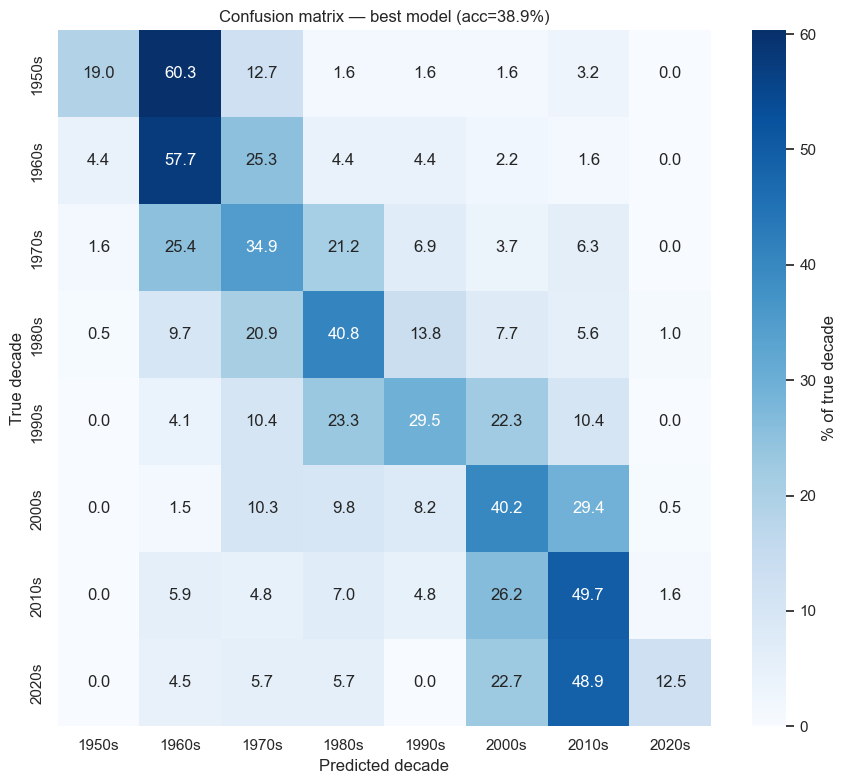


Prediction accuracy by 'distance' (decades off):
  exactly 0 decade(s) off:  38.9%   (cumulative ≤0:  38.9%)
  exactly 1 decade(s) off:  39.0%   (cumulative ≤1:  77.9%)
  exactly 2 decade(s) off:  12.0%   (cumulative ≤2:  89.9%)
  exactly 3 decade(s) off:   5.3%   (cumulative ≤3:  95.2%)
  exactly 4 decade(s) off:   2.8%   (cumulative ≤4:  98.0%)


In [7]:
# Use the best model — usually the combined one
best_pred = pred_combined
decade_labels = sorted(df_clf["decade"].unique())

cm = confusion_matrix(y_test, best_pred, labels=decade_labels)
cm_pct = cm / cm.sum(axis=1, keepdims=True) * 100

fig, ax = plt.subplots(figsize=(9, 8))
sns.heatmap(
    cm_pct, annot=True, fmt=".1f", cmap="Blues",
    xticklabels=[f"{d}s" for d in decade_labels],
    yticklabels=[f"{d}s" for d in decade_labels],
    cbar_kws={"label": "% of true decade"}, ax=ax,
)
ax.set_xlabel("Predicted decade")
ax.set_ylabel("True decade")
ax.set_title(f"Confusion matrix — best model (acc={acc_combined*100:.1f}%)")
plt.tight_layout()
plt.show()

# Mean off-by-N analysis
true_idx = np.searchsorted(decade_labels, y_test)
pred_idx = np.searchsorted(decade_labels, best_pred)
off_by = np.abs(true_idx - pred_idx)
print(f"\nPrediction accuracy by 'distance' (decades off):")
for k in range(5):
    pct = (off_by == k).mean() * 100
    cum = (off_by <= k).mean() * 100
    print(f"  exactly {k} decade(s) off: {pct:5.1f}%   (cumulative ≤{k}: {cum:5.1f}%)")

## Feature importance: what gives the decade away?

For each decade, find the TF-IDF features with the largest positive weight in the logistic regression model.

In [8]:
# Logistic regression coefficients per class
feature_names = np.array(tfidf.get_feature_names_out())

print("Top 15 most decade-indicative features per decade:")
print("=" * 60)
for i, decade in enumerate(decade_labels):
    coefs = logreg.coef_[i]
    top_idx = coefs.argsort()[::-1][:15]
    print(f"\n--- {decade}s (positive evidence) ---")
    print(", ".join(feature_names[top_idx]))

Top 15 most decade-indicative features per decade:

--- 1950s (positive evidence) ---
heart, thrill, dear, well, moon, my heart, kiss, love, will, blue, darling, true, ee, mine, lee

--- 1960s (positive evidence) ---
sweet, little, darling, now, twist, each, love you, come on, dear, little girl, love me, mine, ll, wah, my baby

--- 1970s (positive evidence) ---
got to, love, woman, lord, love you, morning, child, keep on, sing, again, boogie, hoo, disco, baby baby, such

--- 1980s (positive evidence) ---
ooh, ve got, ve, much, night, tonight, living, your eyes, you ve, oh, the night, love just, ow, eyes, this love

--- 1990s (positive evidence) ---
yo, be there, yeah yeah, will, inside, baby, no no, there, yeah, wanna, to the, nothing, be, oh yeah, will be

--- 2000s (positive evidence) ---
cause, club, girl, this, the club, wanna, uh, yo, gon, shorty, my life, what, uh uh, the one, ya

--- 2010s (positive evidence) ---
up, ayy, oh oh, like, we re, woah, we, tryna, fuck, woo, yeah, bit

## Bonus: year regression

Instead of predicting decade, predict the actual release year. This gives us a continuous "how datable is this song" measure — the mean absolute error in years.

A song correctly placed in its decade (10-year window) corresponds to MAE ≤ 5. We expect MAE in the 8-12 year range overall.

Year regression:
  Mean absolute error: 9.2 years
  R²: 0.647


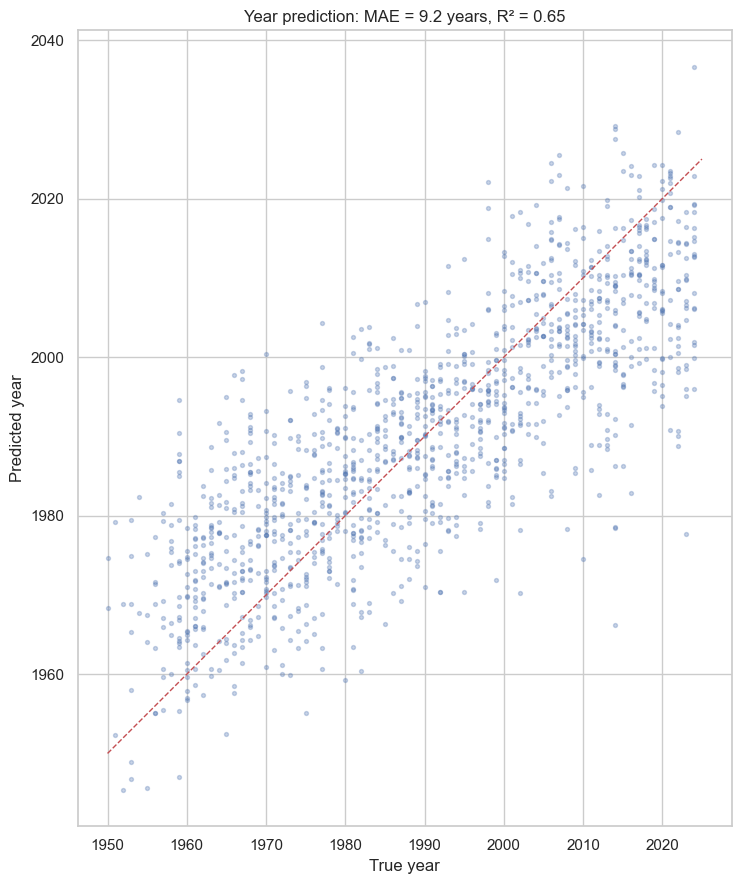


Mean absolute error by decade:
  1950s: 14.3 years
  1960s: 11.2 years
  1970s: 8.2 years
  1980s: 7.4 years
  1990s: 6.9 years
  2000s: 7.8 years
  2010s: 10.1 years
  2020s: 14.0 years


In [9]:
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, r2_score

y_train_year = X_train_df["year"].values
y_test_year = X_test_df["year"].values

ridge = Ridge(alpha=1.0)
ridge.fit(X_train_combined, y_train_year)
pred_year = ridge.predict(X_test_combined)

mae = mean_absolute_error(y_test_year, pred_year)
r2 = r2_score(y_test_year, pred_year)
print(f"Year regression:")
print(f"  Mean absolute error: {mae:.1f} years")
print(f"  R²: {r2:.3f}")

# Scatter: predicted vs actual
fig, ax = plt.subplots(figsize=(9, 9))
ax.scatter(y_test_year, pred_year, alpha=0.3, s=8)
ax.plot([1950, 2025], [1950, 2025], "r--", linewidth=1)
ax.set_xlabel("True year")
ax.set_ylabel("Predicted year")
ax.set_title(f"Year prediction: MAE = {mae:.1f} years, R² = {r2:.2f}")
ax.set_aspect("equal")
plt.tight_layout()
plt.show()

# Which decades have the highest residuals (least datable)?
X_test_df["predicted_year"] = pred_year
X_test_df["residual"] = pred_year - y_test_year
mean_abs_by_decade = (X_test_df.groupby("decade")["residual"]
                                 .apply(lambda x: np.abs(x).mean()))
print(f"\nMean absolute error by decade:")
for dec, mae_d in mean_abs_by_decade.items():
    print(f"  {dec}s: {mae_d:.1f} years")